In [103]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

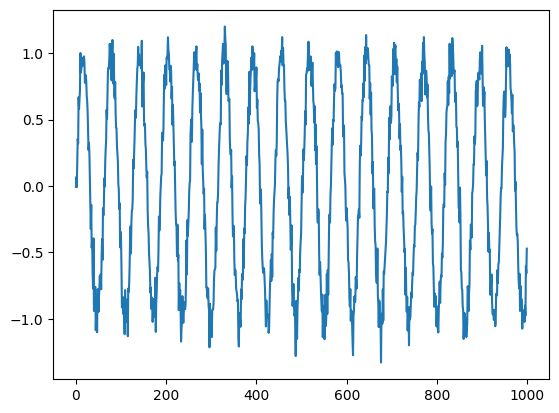

In [104]:
N = 1000
series = np.sin(0.1*np.arange(N)) + np.random.randn(N)*0.1

plt.plot(series)
plt.show()

In [105]:
#Build dataset
T = 10
X = []
Y = []

for t in range (len(series) - T):
    x = series[t:t+T]
    X.append(x)
    y = series[t+T]
    Y.append(y)
    
X = np.array(X).reshape(-1,T)
Y = np.array(Y).reshape(-1,1)
N = len(X)
print(f'X-shape: {X.shape}, Y-shape: {Y.shape}')

X-shape: (990, 10), Y-shape: (990, 1)


In [106]:
#AGR model
model = nn.Linear(T,1)

In [107]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [108]:
X_train = torch.from_numpy(X[:-N//2].astype(np.float32))
X_test = torch.from_numpy(X[-N//2:].astype(np.float32))
y_train = torch.from_numpy(Y[:-N//2].astype(np.float32)) 
y_test = torch.from_numpy(Y[-N//2:].astype(np.float32))

In [109]:
#Training

def full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=200):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        optimizer.zero_grad()
        
        #Forward pass 
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        #Backward and optimize
        loss.backward()
        optimizer.step()
        
        #Save losses
        train_losses[i] = loss.item()
        
        #Test loss
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses[i] = test_loss.item()
        
        if (i + 1) % 5 == 0:
            print(f'Epoch {i+1}/{epochs}, Train loss: {loss.item():.4f}, Test loss: {test_loss.item():.4f}')
    return train_losses, test_losses

In [110]:
train_losses, test_losses = full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test)

Epoch 5/200, Train loss: 0.1596, Test loss: 0.0459
Epoch 10/200, Train loss: 0.0957, Test loss: 0.0348
Epoch 15/200, Train loss: 0.0814, Test loss: 0.0529
Epoch 20/200, Train loss: 0.0580, Test loss: 0.0536
Epoch 25/200, Train loss: 0.0334, Test loss: 0.0391
Epoch 30/200, Train loss: 0.0201, Test loss: 0.0257
Epoch 35/200, Train loss: 0.0170, Test loss: 0.0201
Epoch 40/200, Train loss: 0.0171, Test loss: 0.0182
Epoch 45/200, Train loss: 0.0166, Test loss: 0.0167
Epoch 50/200, Train loss: 0.0160, Test loss: 0.0160
Epoch 55/200, Train loss: 0.0158, Test loss: 0.0159
Epoch 60/200, Train loss: 0.0157, Test loss: 0.0157
Epoch 65/200, Train loss: 0.0154, Test loss: 0.0155
Epoch 70/200, Train loss: 0.0152, Test loss: 0.0154
Epoch 75/200, Train loss: 0.0151, Test loss: 0.0152
Epoch 80/200, Train loss: 0.0149, Test loss: 0.0150
Epoch 85/200, Train loss: 0.0148, Test loss: 0.0149
Epoch 90/200, Train loss: 0.0147, Test loss: 0.0147
Epoch 95/200, Train loss: 0.0145, Test loss: 0.0146
Epoch 100/200

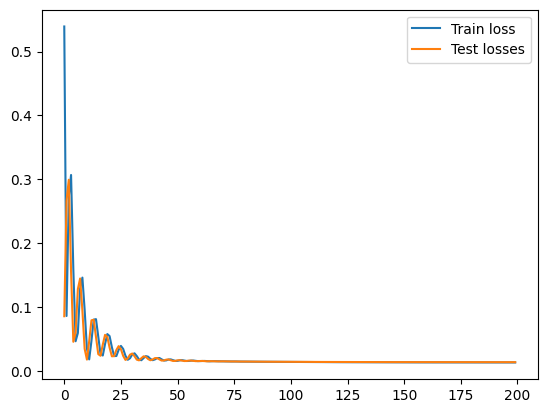

In [111]:
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test losses')
plt.legend()
plt.show()

In [112]:
#Forecast
validation_target = Y[-N//2:]
validation_predictions = []

last_x = torch.from_numpy(X[-N//2].astype(np.float32))

while len(validation_predictions) < len(validation_target):
    input_ = last_x.view(1,-1)
    p = model(input_)
    
    validation_predictions.append(p[0,0].item())
    last_x = torch.cat((last_x[1:], p[0]))

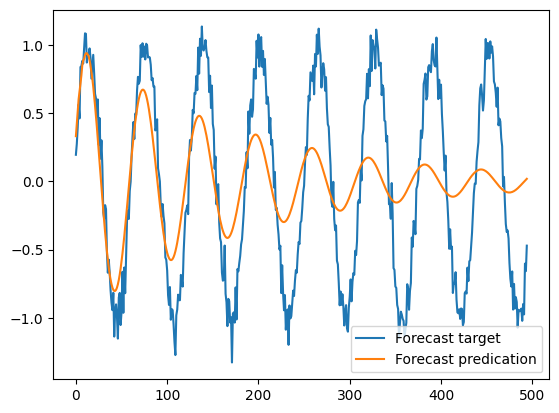

In [113]:
plt.plot(validation_target, label = 'Forecast target')
plt.plot(validation_predictions, label = 'Forecast predication')
plt.legend()